In [13]:
library(tidyverse)
library(tis)
library(baseballr)
library(hoopR)
library(MASS)


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




In [2]:
setwd('..')
getwd()

#source('./code/filter-and-add-features.r')

[1] "/accounts/masters/ben_khothsombath/repos/230A-final-project"

Loading OD Data...
Printing working directory:  /accounts/masters/ben_khothsombath/repos/230A-final-project 


Rows: 67770440 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): origin, destination
dbl  (2): hour, ridership
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Filtering...


`summarise()` has grouped output by 'date', 'hour'. You can override using the
`.groups` argument.


Adding features...
Exporting final dataset...
Done!


In [3]:
df <- read_csv("./data/final-dataset.csv")
dim(df)

Rows: 1130841 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): destination, day, season
dbl  (2): hour, ridership
lgl  (9): destination_green, destination_red, destination_yellow, destinatio...
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 1130841      15

In [4]:
head(df)

date,hour,destination,ridership,day,destination_green,destination_red,destination_yellow,destination_blue,destination_orange,is_holiday,is_giants_home,is_as_home,warriors_at_chase,season
<date>,<dbl>,<chr>,<dbl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>
2023-01-01,0,12TH,63,sunday,FALSE,TRUE,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,winter
2023-01-01,0,16TH,78,sunday,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,winter
2023-01-01,0,19TH,27,sunday,FALSE,TRUE,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,winter
2023-01-01,0,24TH,72,sunday,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,winter
2023-01-01,0,ANTC,13,sunday,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,winter
2023-01-01,0,ASHB,15,sunday,FALSE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,winter


In [5]:
print(format(object.size(df), units = "GB"))

[1] "0.1 Gb"


In [20]:
# Split into Training and Testing sets

train <- df %>% filter(year(date) < 2025)
test <- df %>% filter(year(date) == 2025)

# Treat hour as a factor
train <- train %>% mutate(hour = as_factor(hour))
test <- test %>% mutate(hour = as_factor(hour))

print(dim(train))
print(dim(test))

[1] 754747     10
[1] 376094     10


In [21]:
basic_lm <- lm(ridership~., data=train[, -c(1)])
summary(basic_lm)
#plot(basic_lm)


Call:
lm(formula = ridership ~ ., data = train[, -c(1)])

Residuals:
   Min     1Q Median     3Q    Max 
-643.4  -55.4   -6.1   40.6 5212.9 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)             40.8235     1.9799  20.619  < 2e-16 ***
hour1                  -12.0001     1.4884  -8.062 7.51e-16 ***
hour2                   21.3255     3.5417   6.021 1.73e-09 ***
hour3                 -238.8812     6.2557 -38.186  < 2e-16 ***
hour4                  -91.2979     2.2668 -40.276  < 2e-16 ***
hour5                   -8.2757     1.5481  -5.346 9.01e-08 ***
hour6                   72.0489     1.4835  48.568  < 2e-16 ***
hour7                  168.6822     1.4360 117.467  < 2e-16 ***
hour8                  245.8035     1.4183 173.310  < 2e-16 ***
hour9                  177.4794     1.4157 125.361  < 2e-16 ***
hour10                 109.9593     1.4157  77.670  < 2e-16 ***
hour11                  96.8777     1.4158  68.425  < 2e-16 ***
hour12     

In [22]:
# Log-transformed lm
log_lm <- lm(log(ridership) ~ ., data=train[, -c(1)])
summary(log_lm)
#plot(log_lm)


Call:
lm(formula = log(ridership) ~ ., data = train[, -c(1)])

Residuals:
    Min      1Q  Median      3Q     Max 
-5.6802 -0.3228  0.0037  0.3494  5.0606 

Coefficients:
                       Estimate Std. Error  t value Pr(>|t|)    
(Intercept)            3.164718   0.006921  457.243  < 2e-16 ***
hour1                 -1.469782   0.005203 -282.470  < 2e-16 ***
hour2                 -1.714138   0.012381 -138.447  < 2e-16 ***
hour3                 -3.226646   0.021869 -147.546  < 2e-16 ***
hour4                 -2.489483   0.007924 -314.154  < 2e-16 ***
hour5                 -0.433319   0.005412  -80.068  < 2e-16 ***
hour6                  0.912438   0.005186  175.946  < 2e-16 ***
hour7                  1.377228   0.005020  274.350  < 2e-16 ***
hour8                  1.773581   0.004958  357.716  < 2e-16 ***
hour9                  1.634921   0.004949  330.342  < 2e-16 ***
hour10                 1.459760   0.004949  294.954  < 2e-16 ***
hour11                 1.468066   0.004949  296.

In [23]:
poisson_lm <- glm(ridership ~ ., data = train[, -c(1)], family = poisson(link = "log"))
summary(poisson_lm)


Call:
glm(formula = ridership ~ ., family = poisson(link = "log"), 
    data = train[, -c(1)])

Coefficients:
                        Estimate Std. Error  z value Pr(>|z|)    
(Intercept)            3.0554494  0.0013326  2292.76   <2e-16 ***
hour1                 -1.3831462  0.0027807  -497.42   <2e-16 ***
hour2                 -1.5549157  0.0098150  -158.42   <2e-16 ***
hour3                 -3.4075701  0.0226773  -150.26   <2e-16 ***
hour4                 -2.4834039  0.0064054  -387.70   <2e-16 ***
hour5                  0.4111331  0.0015202   270.44   <2e-16 ***
hour6                  1.5269704  0.0012679  1204.30   <2e-16 ***
hour7                  2.1879591  0.0012040  1817.28   <2e-16 ***
hour8                  2.5322328  0.0011851  2136.76   <2e-16 ***
hour9                  2.2371284  0.0011998  1864.52   <2e-16 ***
hour10                 1.8193425  0.0012294  1479.87   <2e-16 ***
hour11                 1.7134905  0.0012389  1383.05   <2e-16 ***
hour12                 1.731359

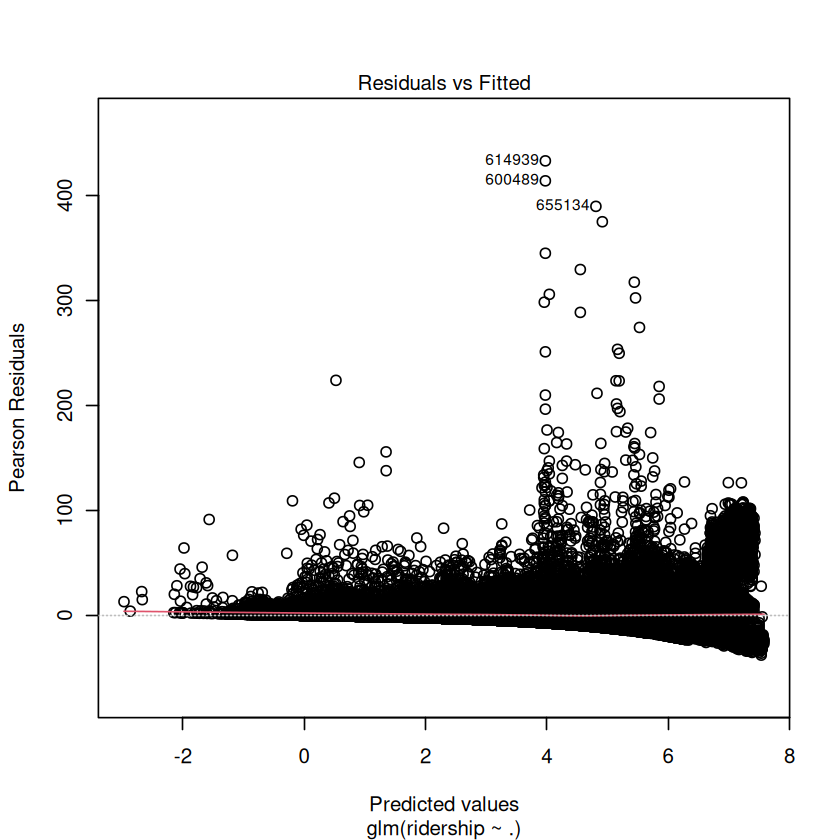

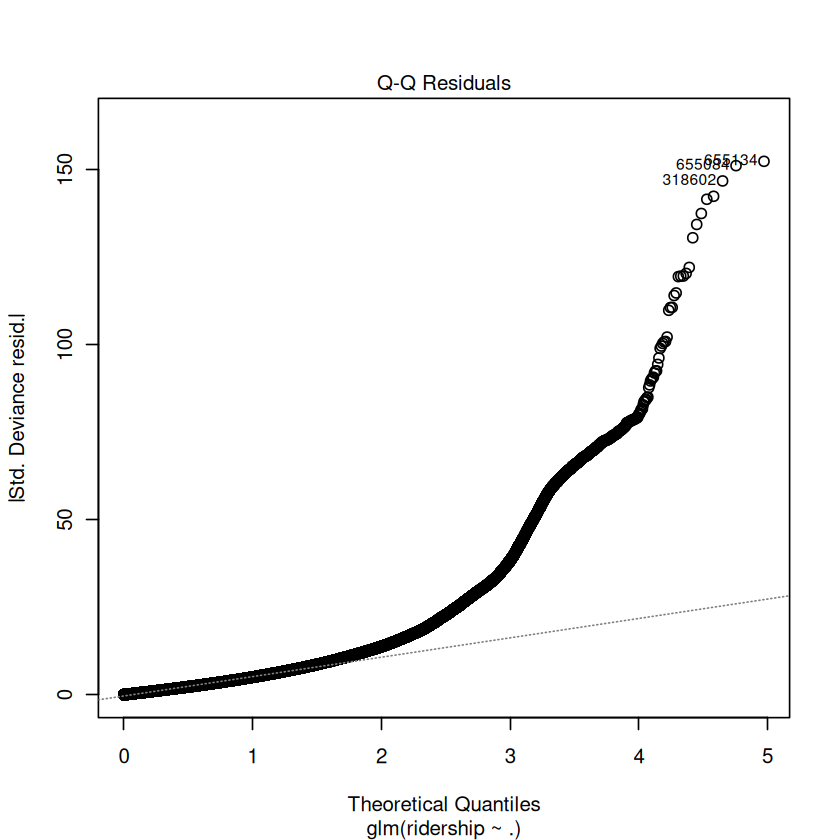

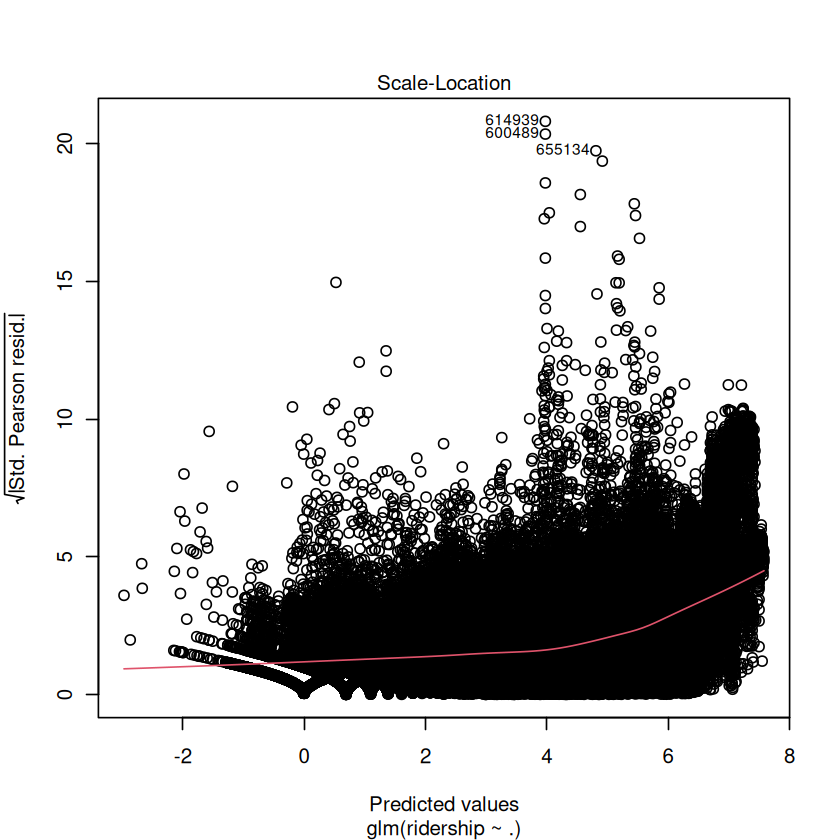

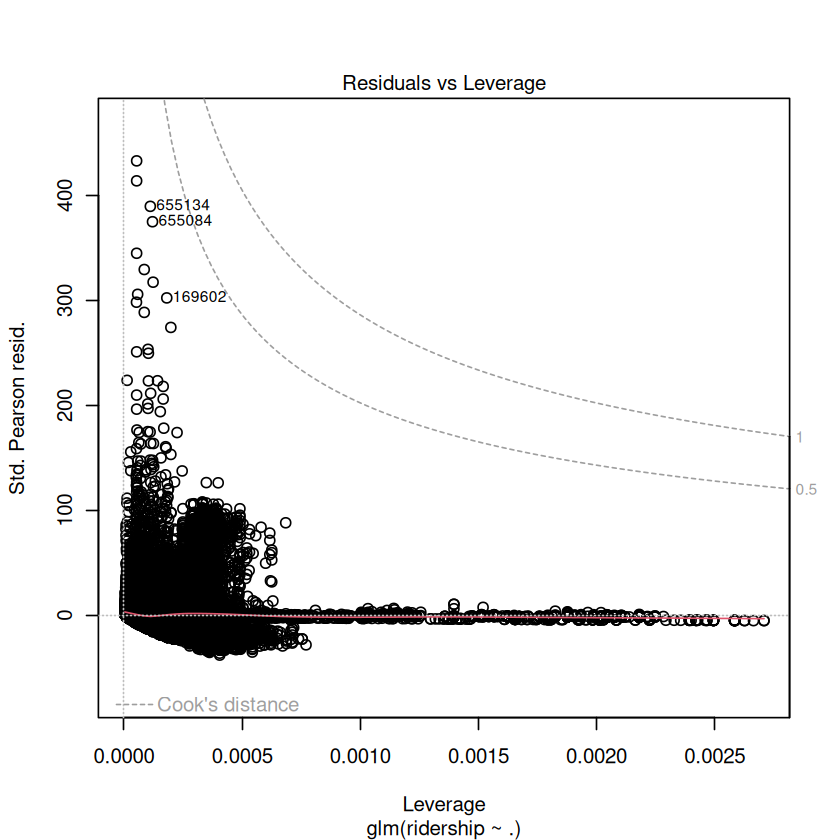

In [24]:
#plot(poisson_lm)

In [25]:
model_nb <- glm.nb(ridership ~ ., data = train[, -c(1)])
summary(model_nb)


Call:
glm.nb(formula = ridership ~ ., data = train[, -c(1)], init.theta = 3.1850146, 
    link = log)

Coefficients:
                       Estimate Std. Error  z value Pr(>|z|)    
(Intercept)            3.572892   0.006031  592.418   <2e-16 ***
hour1                 -1.349761   0.005195 -259.840   <2e-16 ***
hour2                 -1.541870   0.014219 -108.435   <2e-16 ***
hour3                 -3.541680   0.028867 -122.690   <2e-16 ***
hour4                 -2.619377   0.009536 -274.695   <2e-16 ***
hour5                 -0.311511   0.004959  -62.811   <2e-16 ***
hour6                  0.869317   0.004607  188.710   <2e-16 ***
hour7                  1.450069   0.004438  326.743   <2e-16 ***
hour8                  1.701822   0.004379  388.628   <2e-16 ***
hour9                  1.466418   0.004381  334.730   <2e-16 ***
hour10                 1.232497   0.004392  280.641   <2e-16 ***
hour11                 1.232990   0.004392  280.740   <2e-16 ***
hour12                 1.320800   0.0